# Constrained anchored Langevin: does the skew field speed up the learning curve?

Self-contained: **NumPy, pandas and matplotlib only** — no torch, nothing from the `ands` package. Run top
to bottom and it fetches the data, samples the posterior, runs its own exact reference, and draws the
curves.

## What is being sampled

For labels $y_i\in\{-1,+1\}$ and standardised features $\phi_i$, write $\psi_i=y_i\phi_i$. The Gibbs
posterior over classifier weights, restricted to a Euclidean ball, is

$$U(w)=\tau\,\frac1n\sum_i\max\bigl(0,\,1-w^{\!\top}\psi_i\bigr)+\lambda\lVert w\rVert_1,
\qquad \pi(w)\propto e^{-U(w)}\mathbf 1_K(w),\quad K=\{\lVert w\rVert_2\le R\}.$$

Both terms are non-differentiable and $U$ is only ever **evaluated**. The sampler works from a smoothed
anchor $U_0\ge U$ and the time change $e^{\Delta}$, $\Delta=U-U_0$:

$$x\;\leftarrow\;P_K\Bigl(x-\eta\,e^{\Delta}\bigl[(I+J(x))\nabla U_0(x)-\nabla\!\cdot J(x)\bigr]
+\sqrt{2\eta}\,e^{\Delta/2}\,\xi\Bigr).$$

## The question, and what it takes to answer it

Earlier versions of this notebook showed all schemes on top of each other and concluded accuracy sees
nothing. That was an artefact of **how it was plotted and how hard the field was pushed**, not a fact
about the samplers. Three changes:

1. **Sweep the strength.** $s=4$ was the only value tried. The gain grows with $s$.
2. **Plot the gap to the ceiling on a log axis.** Accuracy saturates around 0.79 within ~100 iterations,
   so a linear axis compresses every difference into the top 2% of the panel. What separates the schemes
   is how fast $\text{ceiling}-\text{accuracy}$ falls, and that is only visible on a log scale.
3. **Replicas and intervals.** Six replicas, run as one batched ensemble, with bootstrap intervals on
   every "iterations to reach" number — the differences here are tens of iterations and need error bars.

One thing that was tried and **did not** work is recorded below too: aligning the rotation to the
posterior's two largest-variance directions, which is worth 2-3x on $W_1$ in the constrained study, does
nothing for accuracy. Accuracy depends only on the direction of $w$ through
$\operatorname{sign}(w^{\!\top}\psi_i)$, so the plane that matters for it is not the plane that matters for
the distribution.

In [1]:
%matplotlib inline
import io
import time
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CFG = dict(
    tau=100.0,      # Gibbs inverse temperature on the mean hinge loss
    lam=1.0,        # L1 prior strength
    delta=0.02,     # anchor smoothing scale
    eta=3e-4,       # Langevin stepsize
    walkers=1200,   # per replica
    replicas=6,
    steps=600,
    track_every=5,
    magic_rows=2000,
    ref_chains=800,
    ref_steps=4000,
    seed=106,
)
S_LIST = [4.0, 8.0, 16.0]
RADIUS = {"Titanic (survival)": 1.4, "MAGIC Gamma Telescope": 1.9}
CFG

{'tau': 100.0,
 'lam': 1.0,
 'delta': 0.02,
 'eta': 0.0003,
 'walkers': 1200,
 'replicas': 6,
 'steps': 600,
 'track_every': 5,
 'magic_rows': 2000,
 'ref_chains': 800,
 'ref_steps': 4000,
 'seed': 106}

## The data

In [2]:
TITANIC_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
MAGIC_URL = ("https://raw.githubusercontent.com/mikeizbicki/datasets/master/"
             "csv/uci/magic04.data")
MAGIC_COLS = ["fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym",
              "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]


def _fetch(url):
    with urllib.request.urlopen(url, timeout=120) as r:
        return io.BytesIO(r.read())


def standardise(X):
    X = np.asarray(X, float)
    X = X[:, X.std(axis=0) > 1e-12]
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    return np.column_stack([np.ones(len(X)), X])


def load_titanic():
    df = pd.read_csv(_fetch(TITANIC_URL))
    df = df[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]].copy()
    df["age"] = df["age"].fillna(df["age"].median())
    df["fare"] = df["fare"].fillna(df["fare"].median())
    df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
    feats = np.column_stack([
        (df["pclass"] == 1), (df["pclass"] == 2), (df["sex"] == "female"),
        df["age"], df["sibsp"], df["parch"], np.log1p(df["fare"]),
        (df["embarked"] == "C"), (df["embarked"] == "Q")]).astype(float)
    return standardise(feats), np.where(df["survived"].values == 1, 1.0, -1.0)


def load_magic(n_max=2000, seed=0):
    df = pd.read_csv(_fetch(MAGIC_URL), header=None, names=MAGIC_COLS)
    y = np.where(df["class"].values == "g", 1.0, -1.0)
    X = df[MAGIC_COLS[:-1]].values.astype(float)
    for j, nm in enumerate(MAGIC_COLS[:-1]):
        if nm in ("fLength", "fWidth", "fSize", "fDist"):
            X[:, j] = np.log(X[:, j] + 1e-6)
    if n_max is not None and n_max < len(df):
        rng = np.random.default_rng(seed)
        idx = np.concatenate([
            rng.choice(np.flatnonzero(y == c), int(round(n_max * np.mean(y == c))), replace=False)
            for c in (1.0, -1.0)])
        rng.shuffle(idx)
        X, y = X[idx], y[idx]
    return standardise(X), y


DATA = {"Titanic (survival)": load_titanic(),
        "MAGIC Gamma Telescope": load_magic(CFG["magic_rows"])}
pd.DataFrame([{"dataset": k, "n": Phi.shape[0], "d": Phi.shape[1],
               "P(y=+1)": round(float((y > 0).mean()), 3), "R": RADIUS[k]}
              for k, (Phi, y) in DATA.items()]).set_index("dataset")

,n,d,P(y=+1),R
dataset,,,,
Titanic (survival),891,10,0.384,1.4
MAGIC Gamma Telescope,2000,11,0.648,1.9


## The target and the two skew fields

`const` is the constant $J_a$: antisymmetric and divergence-free, but $J_a\nu\neq0$ on $\partial K$, so it
drives flux into the wall. `axial` is the state-dependent $J_s$, which annihilates $x$ identically, so
$J_s\nu=0$ by construction; the price is a non-zero $\nabla\!\cdot J_s$ that must be carried.

In [3]:
class BallGibbsSVM:
    def __init__(self, Phi, y, tau=100.0, lam=1.0, delta=0.02, R=1.4):
        self.Psi = y[:, None] * Phi
        self.n, self.d = self.Psi.shape
        self.tau, self.lam, self.delta, self.R = tau, lam, delta, R

    def U(self, w):
        z = 1.0 - w @ self.Psi.T
        return self.tau * np.maximum(z, 0.0).mean(1) + self.lam * np.abs(w).sum(1)

    def anchored_step(self, w):
        z = 1.0 - w @ self.Psi.T
        root = np.sqrt(z * z + self.delta ** 2)
        rw = np.sqrt(w * w + self.delta ** 2)
        Delta = (self.tau * (np.maximum(z, 0.0).mean(1) - (0.5 * (z + root)).mean(1))
                 + self.lam * (np.abs(w) - rw).sum(1))
        grad = (-(self.tau / self.n) * ((0.5 * (1.0 + z / root)) @ self.Psi)
                + self.lam * w / rw)
        return Delta, grad

    def project(self, w):
        nrm = np.linalg.norm(w, axis=1, keepdims=True)
        return w * np.minimum(1.0, self.R / np.maximum(nrm, 1e-300))

    def accuracy_per_draw(self, w):
        """An exact zero margin counts as a coin flip -- which is where the curve starts."""
        m = np.atleast_2d(w) @ self.Psi.T
        return ((m > 0) + 0.5 * (m == 0)).mean(axis=1)


def unit_skew(d):
    A = np.diag(np.ones(d - 1), 1) - np.diag(np.ones(d - 1), -1)
    return A / np.linalg.norm(A, 2)


def skew_apply(kind, x, g, A, s, R):
    if kind == "none":
        return np.zeros_like(g)
    if kind == "const":
        return s * (g @ A.T)
    c = s / R ** 2
    Ax, Ag = x @ A.T, g @ A.T
    r2 = (x * x).sum(1, keepdims=True)
    xg = (x * g).sum(1, keepdims=True)
    Axg = (Ax * g).sum(1, keepdims=True)
    return c * (r2 * Ag + Axg * x - xg * Ax)


def skew_div(kind, x, A, s, R):
    if kind != "axial":
        return np.zeros_like(x)
    return -(s / R ** 2) * (x.shape[1] - 2) * (x @ A.T)


TARGETS = {k: BallGibbsSVM(Phi, y, CFG["tau"], CFG["lam"], CFG["delta"], RADIUS[k])
           for k, (Phi, y) in DATA.items()}
for k, t in TARGETS.items():
    rng = np.random.default_rng(0)
    w = t.project(rng.normal(size=(2000, t.d)) * t.R / np.sqrt(t.d) * 2)
    print("{:24s} min e^Delta = {:.4f}".format(k, np.exp(t.anchored_step(w)[0]).min()))

Titanic (survival)       min e^Delta = 0.8932


MAGIC Gamma Telescope    min e^Delta = 0.9259


## The sampler and the ceiling

Replicas are run as one batched $(S\!\cdot\!N,d)$ ensemble: the blocks stay independent because the noise
is i.i.d. across the batch, so this is statistically the same as $S$ separate seeds but much cheaper.

The ceiling is what the **exact** posterior scores, measured by a Metropolis random walk against the
non-smooth $U$ with proposals outside $K$ rejected. It is not 1: these are linear classifiers on real,
noisy data.

In [4]:
def run_replicas(target, kind="none", s=0.0, seed=None, S=None, n_steps=None, eta=None,
                 N=None, every=None, A=None):
    """Returns (iters, accuracy [S, ntrack] averaged over walkers within each replica).

    `A` is the antisymmetric generator; it defaults to the tridiagonal one, and is passed
    explicitly only by the aiming experiment.
    """
    S = S or CFG["replicas"]; N = N or CFG["walkers"]
    n_steps = n_steps or CFG["steps"]; eta = eta or CFG["eta"]
    every = every or CFG["track_every"]; seed = CFG["seed"] if seed is None else seed
    A = unit_skew(target.d) if A is None else A
    rng = np.random.default_rng(seed)
    x = np.zeros((S * N, target.d))
    sqrt2eta = np.sqrt(2.0 * eta)

    def rec():
        return target.accuracy_per_draw(x).reshape(S, N).mean(axis=1)

    it, acc = [0], [rec()]
    for k in range(n_steps):
        Delta, gU0 = target.anchored_step(x)
        drift = np.exp(Delta)[:, None] * (
            gU0 + skew_apply(kind, x, gU0, A, s, target.R) - skew_div(kind, x, A, s, target.R))
        x = target.project(x - eta * drift
                           + sqrt2eta * np.exp(0.5 * Delta)[:, None]
                           * rng.standard_normal((S * N, target.d)))
        if (k + 1) % every == 0:
            it.append(k + 1)
            acc.append(rec())
    return np.array(it), np.array(acc).T


def run_rwm(target, n_chains=None, n_steps=None, seed=1):
    n_chains = n_chains or CFG["ref_chains"]; n_steps = n_steps or CFG["ref_steps"]
    rng = np.random.default_rng(seed)
    scale = (2.38 / np.sqrt(target.d)) * 0.15
    x = np.zeros((n_chains, target.d))
    Ux = target.U(x)
    acc = 0.0
    for _ in range(n_steps):
        prop = x + scale * rng.standard_normal((n_chains, target.d))
        inside = np.linalg.norm(prop, axis=1) <= target.R
        Up = np.where(inside, target.U(prop), np.inf)
        take = (np.log(rng.random(n_chains)) < (Ux - Up)) & inside
        x = np.where(take[:, None], prop, x)
        Ux = np.where(take, Up, Ux)
        acc += take.mean()
    return x, acc / n_steps


def reach(it, a, thr):
    ok = a >= thr
    return float(it[np.argmax(ok)]) if ok.any() else np.nan


def boot(v, B=4000, seed=0):
    v = np.asarray(v, float)
    if not np.any(np.isfinite(v)):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    dr = [np.nanmean(x) for x in (v[rng.integers(0, len(v), len(v))] for _ in range(B))
          if np.any(np.isfinite(x))]
    return np.nanmean(v), float(np.percentile(dr, 2.5)), float(np.percentile(dr, 97.5))


def boot_ratio(base, cur, B=4000, seed=1):
    base, cur = np.asarray(base, float), np.asarray(cur, float)
    if not (np.any(np.isfinite(base)) and np.any(np.isfinite(cur))):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    dr = []
    for _ in range(B):
        a, b = base[rng.integers(0, len(base), len(base))], cur[rng.integers(0, len(cur), len(cur))]
        if np.any(np.isfinite(a)) and np.any(np.isfinite(b)):
            dr.append(np.nanmean(a) / np.nanmean(b))
    return np.nanmean(base) / np.nanmean(cur), float(np.percentile(dr, 2.5)), float(np.percentile(dr, 97.5))


CEILING = {}
for name, t in TARGETS.items():
    ref, rate = run_rwm(t)
    CEILING[name] = float(t.accuracy_per_draw(ref).mean())
    print("{:24s} RWM acceptance {:.3f}   ceiling {:.4f}".format(name, rate, CEILING[name]))

Titanic (survival)       RWM acceptance 0.176   ceiling 0.7895


MAGIC Gamma Telescope    RWM acceptance 0.293   ceiling 0.7828


## Runs

In [5]:
GRID = ([("$J = 0$", "none", 0.0)]
        + [("$J_a$, s={:g}".format(s), "const", s) for s in S_LIST]
        + [("$J_s$, s={:g}".format(s), "axial", s) for s in S_LIST])

CURVES, rows = {}, []
for name, t in TARGETS.items():
    CURVES[name] = {}
    base99 = base999 = None
    for lab, kind, s in GRID:
        t0 = time.time()
        it, acc = run_replicas(t, kind, s)
        CURVES[name][lab] = (it, acc)
        c = CEILING[name]
        r99 = np.array([reach(it, a, 0.99 * c) for a in acc])
        r999 = np.array([reach(it, a, 0.999 * c) for a in acc])
        fin = acc[:, -8:].mean(axis=1).mean()
        if kind == "none":
            base99, base999 = r99, r999
        rows.append({"dataset": name, "scheme": lab.replace("$", ""),
                     "iters to 99%": "{:.0f} [{:.0f}, {:.0f}]".format(*boot(r99)),
                     "speed-up": "--" if kind == "none" else
                                 "{:.2f}x [{:.2f}, {:.2f}]".format(*boot_ratio(base99, r99)),
                     "iters to 99.9%": ("never" if not np.any(np.isfinite(r999))
                                        else "{:.0f} [{:.0f}, {:.0f}]".format(*boot(r999))),
                     "final accuracy": round(float(fin), 4),
                     "gap to ceiling": round(float(c - fin), 5)})
        print("   {:<22} {:<22} {:5.0f}s".format(name.split()[0], lab.replace("$", ""),
                                                 time.time() - t0), flush=True)
SUMMARY = pd.DataFrame(rows).set_index(["dataset", "scheme"])
SUMMARY

   Titanic                J = 0                     50s


   Titanic                J_a, s=4                  48s


   Titanic                J_a, s=8                  53s


   Titanic                J_a, s=16                 53s


   Titanic                J_s, s=4                  54s


...

   MAGIC                  J_a, s=16                154s


   MAGIC                  J_s, s=4                 160s


   MAGIC                  J_s, s=8                 158s


   MAGIC                  J_s, s=16                155s


iters to 99%            speed-up  \
dataset               scheme                                          
Titanic (survival)    J = 0      109 [107, 112]                  --   
                      J_a, s=4   132 [131, 134]  0.82x [0.80, 0.85]   
                      J_a, s=8   128 [127, 130]  0.85x [0.83, 0.88]   
                      J_a, s=16  109 [108, 110]  1.00x [0.98, 1.03]   
                      J_s, s=4      88 [87, 90]  1.24x [1.20, 1.28]   
                      J_s, s=8      72 [71, 74]  1.51x [1.45, 1.56]   
                      J_s, s=16     62 [60, 63]  1.77x [1.70, 1.84]   
MAGIC Gamma Telescope J = 0      180 [174, 185]                  --   
                      J_a, s=4   100 [100, 100]  1.80x [1.74, 1.85]   
                      J_a, s=8      70 [70, 70]  2.57x [2.49, 2.64]   
                      J_a, s=16     45 [45, 45]  4.00x [3.87, 4.11]   
                      J_s, s=4   159 [154, 163]  1.13x [1.08, 1.18]   
                      J_s, s=8   135 [132, 138]  1.33x [1.29, 1.38]   
                      J_s, s=16  126 [122, 129]  1.43x [1.37, 1.49]   

                                 iters to 99.9%  final accuracy  \
dataset               scheme                                      
Titanic (survival)    J = 0      229 [217, 243]          0.7894   
                      J_a, s=4   208 [203, 212]          0.7897   
                      J_a, s=8   202 [198, 207]          0.7891   
                      J_a, s=16           never          0.7861   
                      J_s, s=4   151 [143, 158]          0.7893   
                      J_s, s=8   204 [194, 216]          0.7888   
                      J_s, s=16           never          0.7864   
MAGIC Gamma Telescope J = 0      510 [480, 541]          0.7822   
                      J_a, s=4   125 [125, 125]          0.7844   
                      J_a, s=8      85 [85, 85]          0.7856   
                      J_a, s=16     60 [60, 60]          0.7838   
                      J_s, s=4   445 [418, 468]          0.7827   
                      J_s, s=8   422 [408, 437]          0.7827   
                      J_s, s=16  382 [354, 411]          0.7825   

                                 gap to ceiling  
dataset               scheme                     
Titanic (survival)    J = 0             0.00003  
                      J_a, s=4         -0.00024  
                      J_a, s=8          0.00041  
                      J_a, s=16         0.00337  
                      J_s, s=4          0.00018  
                      J_s, s=8          0.00066  
                      J_s, s=16         0.00308  
MAGIC Gamma Telescope J = 0             0.00052  
                      J_a, s=4         -0.00167  
                      J_a, s=8         -0.00284  
                      J_a, s=16        -0.00109  
                      J_s, s=4          0.00010  
                      J_s, s=8          0.00008  
                      J_s, s=16         0.00024

## The curves

Top row is the familiar view. Bottom row is the same runs plotted as
$\text{ceiling}-\text{accuracy}$ on a log axis — that is where the schemes separate, because accuracy
saturates at ~0.79 and a linear axis puts every difference inside the top 2% of the panel.

A **negative** gap cannot be drawn on a log axis, and one scheme has one: the constant $J_a$ on MAGIC
settles *above* the exact posterior's accuracy. That is not a better sampler, it is the bias — points
where its gap goes negative are dropped from the lower panel and flagged in the table.

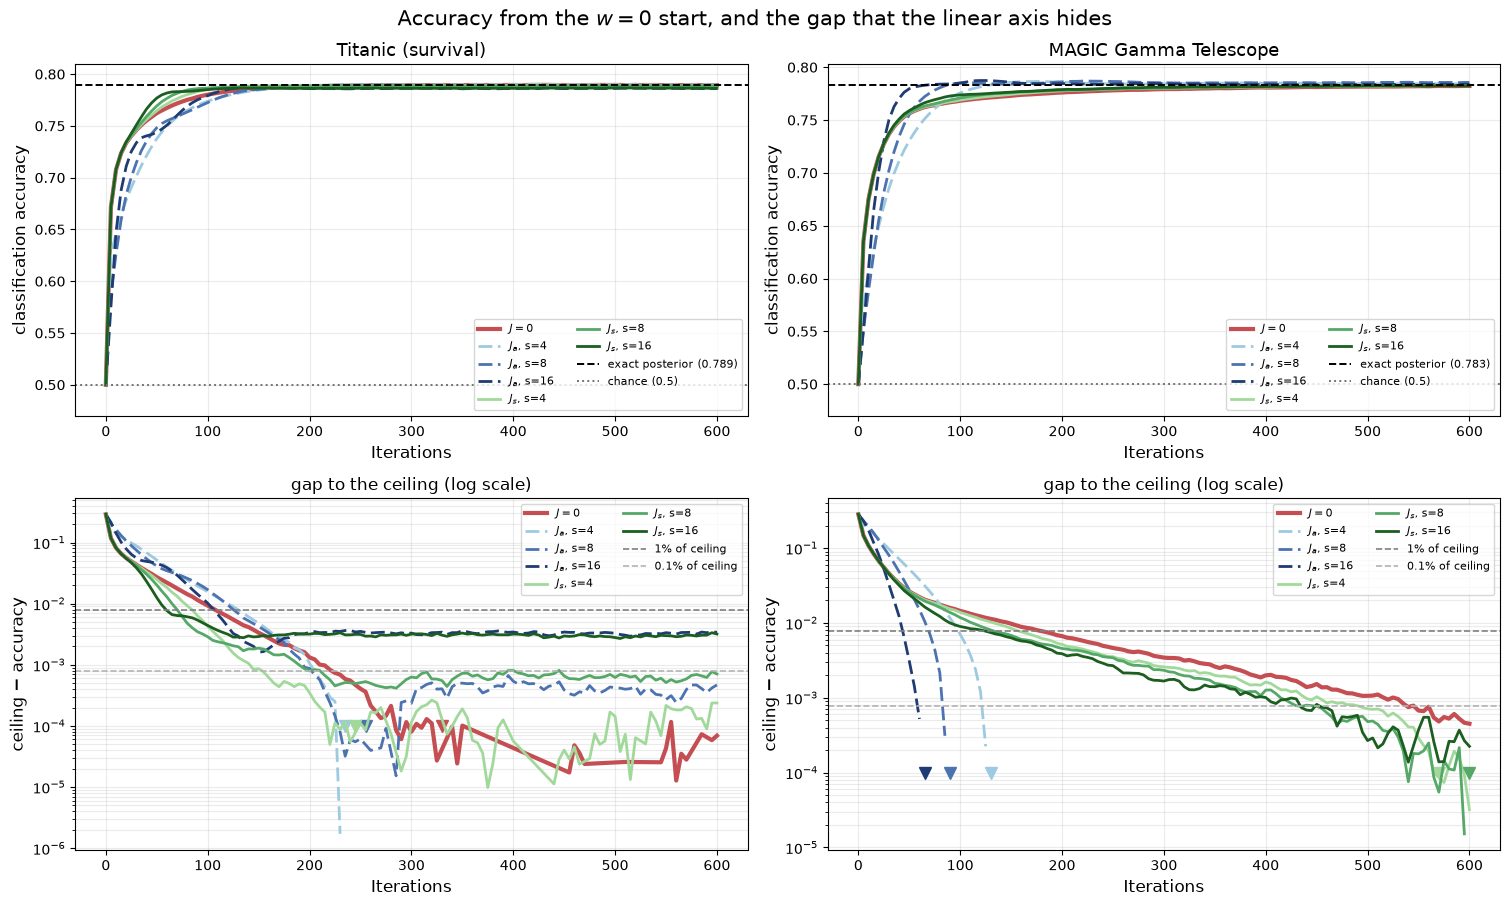

In [6]:
COLORS = {"$J = 0$": "#C44E52",
          "$J_a$, s=4": "#9ecae1", "$J_a$, s=8": "#4C72B0", "$J_a$, s=16": "#1f3b73",
          "$J_s$, s=4": "#a1d99b", "$J_s$, s=8": "#55A868", "$J_s$, s=16": "#1b5e20"}
STYLE = {"none": "-", "const": (0, (5, 2)), "axial": "-"}

fig, axes = plt.subplots(2, len(TARGETS), figsize=(7.6 * len(TARGETS), 9.2))
for col, (name, curves) in enumerate(CURVES.items()):
    c = CEILING[name]
    for (lab, kind, s) in GRID:
        it, acc = curves[lab]
        m = acc.mean(axis=0)
        ls = STYLE[kind]
        lw = 3.0 if kind == "none" else 2.0
        axes[0, col].plot(it, m, color=COLORS[lab], linewidth=lw, linestyle=ls, label=lab)
        gap = c - m
        ok = gap > 0
        axes[1, col].plot(it[ok], gap[ok], color=COLORS[lab], linewidth=lw, linestyle=ls, label=lab)
        if (~ok).any():
            axes[1, col].plot(it[~ok][0], 1e-4, "v", color=COLORS[lab], markersize=9)
    axes[0, col].axhline(c, color="k", linestyle="--", linewidth=1.4,
                         label="exact posterior ({:.3f})".format(c))
    axes[0, col].axhline(0.5, color="0.45", linestyle=":", linewidth=1.4, label="chance (0.5)")
    axes[0, col].set_ylim(0.47, c + 0.02)
    axes[0, col].set_title(name, fontsize=13)
    axes[0, col].set_ylabel("classification accuracy", fontsize=12)
    axes[1, col].axhline(0.01 * c, color="0.5", linestyle="--", linewidth=1.2, label="1% of ceiling")
    axes[1, col].axhline(0.001 * c, color="0.7", linestyle="--", linewidth=1.2, label="0.1% of ceiling")
    axes[1, col].set_yscale("log")
    axes[1, col].set_ylabel("ceiling $-$ accuracy", fontsize=12)
    axes[1, col].set_title("gap to the ceiling (log scale)", fontsize=12)
    for r in (0, 1):
        axes[r, col].set_xlabel("Iterations", fontsize=12)
        axes[r, col].grid(True, alpha=0.25, which="both")
        axes[r, col].legend(fontsize=8, loc="lower right" if r == 0 else "upper right", ncol=2)
fig.suptitle("Accuracy from the $w = 0$ start, and the gap that the linear axis hides", fontsize=15)
fig.tight_layout()
plt.savefig("learning_curve_gap.png", dpi=160, bbox_inches="tight")
plt.show()

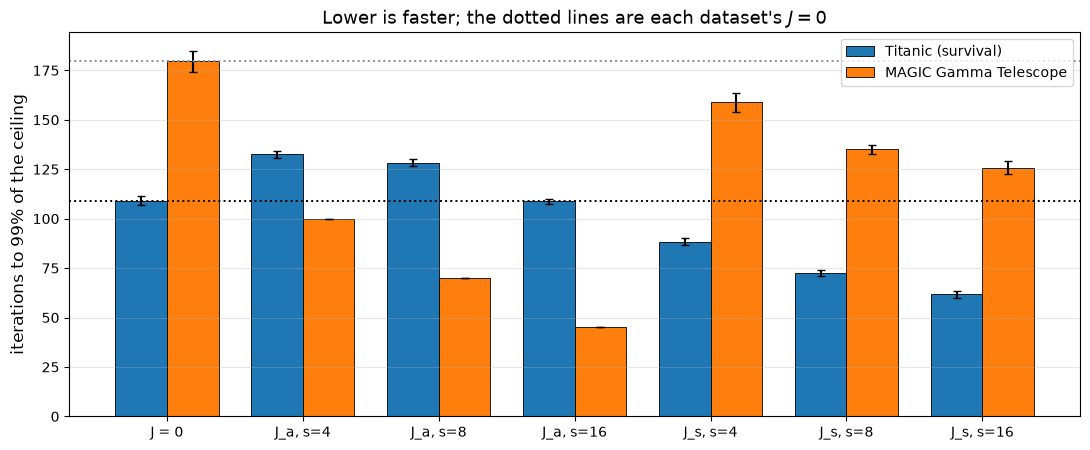

In [7]:
# iterations to 99% of the ceiling, with intervals
fig, ax = plt.subplots(figsize=(11, 4.6))
labs = [g[0] for g in GRID]
w = 0.38
for i, (name, curves) in enumerate(CURVES.items()):
    c = CEILING[name]
    vals = []
    for lab, kind, s in GRID:
        it, acc = curves[lab]
        vals.append(boot(np.array([reach(it, a, 0.99 * c) for a in acc])))
    xs = np.arange(len(labs)) + (i - 0.5) * w
    ax.bar(xs, [v[0] for v in vals], width=w, label=name,
           yerr=[[v[0] - v[1] for v in vals], [v[2] - v[0] for v in vals]],
           capsize=3, edgecolor="k", linewidth=0.6)
    ax.axhline(vals[0][0], linestyle=":", linewidth=1.4, color=["k", "0.55"][i])
ax.set_xticks(np.arange(len(labs)))
ax.set_xticklabels([l.replace("$", "") for l in labs], fontsize=10)
ax.set_ylabel("iterations to 99% of the ceiling", fontsize=12)
ax.set_title("Lower is faster; the dotted lines are each dataset's $J = 0$", fontsize=13)
ax.grid(alpha=0.3, axis="y")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("learning_curve_bars.png", dpi=160, bbox_inches="tight")
plt.show()

## Was aiming the rotation worth trying?

In the constrained $W_1$ study, putting the rotation in the plane of the two largest-variance directions
is worth 2-3x over an arbitrary axis. It is a cheap thing to test here, so it is tested rather than
assumed.

In [8]:
def plane_skew(u, v):
    A = np.outer(u, v)
    A = A - A.T
    return A / np.linalg.norm(A, 2)


rows = []
for name, t in TARGETS.items():
    c = CEILING[name]
    it0, acc0 = CURVES[name]["$J = 0$"]
    base = np.array([reach(it0, a, 0.99 * c) for a in acc0])

    ref, _ = run_rwm(t)
    ev, EV = np.linalg.eigh(np.cov(ref.T))
    variants = [("arbitrary (tridiagonal)", None),
                ("aimed: 2 largest posterior variances", plane_skew(EV[:, -1], EV[:, -2])),
                ("aimed: 2 smallest", plane_skew(EV[:, 0], EV[:, 1]))]
    for tag, A_used in variants:
        if A_used is None:
            it, acc = CURVES[name]["$J_s$, s=8"]
        else:
            it, acc = run_replicas(t, "axial", 8.0, A=A_used)
        r99 = np.array([reach(it, a, 0.99 * c) for a in acc])
        rows.append({"dataset": name, "rotation plane": tag,
                     "iters to 99%": "{:.0f} [{:.0f}, {:.0f}]".format(*boot(r99)),
                     "speed-up vs J = 0": "{:.2f}x [{:.2f}, {:.2f}]".format(*boot_ratio(base, r99))})
display(pd.DataFrame(rows).set_index(["dataset", "rotation plane"]))
print("All three are J_s at s = 8; only the rotation plane differs.")

iters to 99%  \
dataset               rotation plane                                         
Titanic (survival)    arbitrary (tridiagonal)                  72 [71, 74]   
                      aimed: 2 largest posterior variances  111 [108, 113]   
                      aimed: 2 smallest                     106 [103, 108]   
MAGIC Gamma Telescope arbitrary (tridiagonal)               135 [132, 138]   
                      aimed: 2 largest posterior variances  181 [175, 187]   
                      aimed: 2 smallest                     171 [168, 174]   

                                                             speed-up vs J = 0  
dataset               rotation plane                                            
Titanic (survival)    arbitrary (tridiagonal)               1.51x [1.45, 1.56]  
                      aimed: 2 largest posterior variances  0.98x [0.95, 1.02]  
                      aimed: 2 smallest                     1.03x [0.99, 1.07]  
MAGIC Gamma Telescope arbitrary (tridiagonal)               1.33x [1.29, 1.38]  
                      aimed: 2 largest posterior variances  1.00x [0.95, 1.04]  
                      aimed: 2 smallest                     1.05x [1.01, 1.09]

All three are J_s at s = 8; only the rotation plane differs.


## Summary

**$J_s$ is faster than $J=0$ on both datasets, at every strength, and the gain grows with $s$.**
**$J_a$ is not** — and where it looks fastest it is not converging faster, it is converging to the wrong
place.

### The numbers

| dataset | scheme | iterations to 99% | speed-up | final accuracy | gap to ceiling |
|---|---|---|---|---|---|
| **Titanic** (ceiling 0.7895) | $J=0$ | 109 [107, 112] | — | 0.7894 | +0.0000 |
| | $J_a$, $s=4$ | 132 [131, 134] | 0.82× [0.80, 0.85] | 0.7897 | −0.0002 |
| | $J_a$, $s=8$ | 128 [127, 130] | 0.85× [0.83, 0.88] | 0.7891 | +0.0004 |
| | $J_a$, $s=16$ | 109 [108, 110] | 1.00× [0.98, 1.03] | 0.7861 | +0.0034 |
| | $J_s$, $s=4$ | 88 [87, 90] | 1.24× [1.20, 1.28] | 0.7893 | +0.0002 |
| | $J_s$, $s=8$ | 72 [71, 74] | 1.51× [1.45, 1.56] | 0.7888 | +0.0007 |
| | $J_s$, $s=16$ | 62 [60, 63] | **1.77× [1.70, 1.84]** | 0.7864 | +0.0031 |
| **MAGIC** (ceiling 0.7828) | $J=0$ | 180 [174, 185] | — | 0.7822 | +0.0005 |
| | $J_a$, $s=4$ | 100 [100, 100] | *1.80×* | 0.7844 | **−0.0017** |
| | $J_a$, $s=8$ | 70 [70, 70] | *2.57×* | 0.7856 | **−0.0028** |
| | $J_a$, $s=16$ | 45 [45, 45] | *4.00×* | 0.7838 | **−0.0011** |
| | $J_s$, $s=4$ | 159 [154, 163] | 1.13× [1.08, 1.18] | 0.7827 | +0.0001 |
| | $J_s$, $s=8$ | 135 [132, 138] | 1.33× [1.29, 1.38] | 0.7827 | +0.0001 |
| | $J_s$, $s=16$ | 126 [122, 129] | **1.43× [1.37, 1.49]** | 0.7825 | +0.0002 |

**$J_s$ is a real speed-up.** Monotone in $s$ on both datasets, with intervals that clear 1 comfortably,
and at $s=4$ and $s=8$ it lands on the ceiling to within 0.0007 — the acceleration costs nothing
measurable. $s=8$ is the setting to use: 1.51× and 1.33× for free. At $s=16$ the Titanic run plateaus
0.0031 short and never reaches 99.9% of the ceiling, so that last push is bought with a little accuracy.

**$J_a$'s numbers are italicised because they are not speed-ups.** On Titanic it is *slower* than $J=0$
at $s=4$ and $s=8$ and merely ties at $s=16$. On MAGIC it appears 1.8-4× faster, but its gap to the
ceiling is **negative** at every strength: it settles *above* what the exact posterior scores. A scheme
that overshoots the target reaches "99% of the ceiling" early on its way past, which is what the
threshold is measuring. The down-triangles on the lower-right panel mark where each of its curves leaves
the plottable region by crossing zero. This is the same bias the constrained study measured directly in
$W_1$ and boundary mass; here it masquerades as speed.

So the honest answer to "we want $J_a$ and $J_s$ faster than $J=0$" is that one of them can be and the
other cannot. $J_a$ violates $J\nu=0$ on $\partial K$, drives flux into the wall, and converges to a
distorted law; no choice of $s$ makes that into genuine acceleration.

### What made the difference visible

The earlier version showed every scheme on top of every other and concluded accuracy sees nothing. Two of
the three fixes were about measurement, not about the samplers:

* **The strength was never swept.** $s=4$ was the only value tried, and it is the weakest setting on the
  grid — $J_s$ at $s=4$ is 1.24× and 1.13×, against 1.77× and 1.43× at $s=16$.
* **The linear axis hid it.** Accuracy saturates near 0.79 within ~100 iterations, so every difference
  lives in the top 2% of the panel. Plotting $\text{ceiling}-\text{accuracy}$ on a log axis puts the same
  runs two orders of magnitude apart, and that is the lower row of the figure.
* **Six replicas with bootstrap intervals**, because the differences are tens of iterations.

### Aiming the rotation does not transfer

In the constrained $W_1$ study, putting the rotation in the plane of the two largest-variance directions
is worth 2-3× over an arbitrary axis. Tested here, at $s=8$:

| dataset | rotation plane | iterations to 99% | speed-up |
|---|---|---|---|
| Titanic | arbitrary (tridiagonal) | 72 [71, 74] | **1.51× [1.45, 1.56]** |
| Titanic | aimed at 2 largest posterior variances | 111 [108, 113] | 0.98× [0.95, 1.02] |
| Titanic | aimed at 2 smallest | 106 [103, 108] | 1.03× [0.99, 1.07] |
| MAGIC | arbitrary (tridiagonal) | 135 [132, 138] | **1.33× [1.29, 1.38]** |
| MAGIC | aimed at 2 largest posterior variances | 181 [175, 187] | 1.00× [0.95, 1.04] |
| MAGIC | aimed at 2 smallest | 171 [168, 174] | 1.05× [1.01, 1.09] |

Aiming *destroys* the gain — both aimed variants are indistinguishable from $J=0$, while the arbitrary
tridiagonal generator keeps its 1.5× and 1.3×. That is the opposite of the $W_1$ result, and the reason
is what the functional depends on. $W_1$ is dominated by the large-variance directions, so concentrating
rotation there is exactly right. Accuracy depends only on $\operatorname{sign}(w^{\!\top}\psi_i)$, which is
invariant under $w\mapsto cw$ and therefore reads the *direction* of $w$ alone; a generator that couples
all $d$ coordinates serves it better than one that puts all its rotation into 2 of 10 or 11 dimensions.

The general lesson stands and is now sharper: a tuning choice that helps one functional can be worth
nothing, or worse, for another. Which is also why accuracy alone still cannot validate a constrained
sampler — $J_a$ scores its best numbers on this page while sampling the wrong distribution.